# Problem Set 6: Probabilistic Models and Reinforcement Learning

This assignment requires a working IPython Notebook installation, which you should already have. If not, please refer to the instructions in the previous problem sets.

### Submission Guidelines

You need to submit **the output of the notebook as PDF** and **an additional .py file** on Gradescope.

For the .py file, Here are the guidelines :

1. The .py file should contain ONLY your typed codes. (Do not include any other code apart from what you coded for the assignment)

2. .py should NOT contain any written answers. Only code written by you.

3. If your typed code falls under a function definition thats predefined by us, Only include your typed code and nothing else.

4. For each cell block within colab/jupyter that you typed your code in, Add 2 new lines ("\n") before pasting your typed code in the .py file.


 The assignment is graded on completion. You will also need to **answer** whether you attempted the question or not in Gradescope. It is extremely important that you complete all assignments (both the programming and written questions), as they will prepare you for quizzes and exams.

**Total:** 125 points (+20 points bonus).

## 1 Linear Discriminant Analysis (LDA) [50 pts]
In this exercise, we build a linear discriminant analysis (LDA) classifier for the problem of predicting whether a student gets admitted into a university.

LDA is a generative model for classification. Given a training dataset of positive and negative features $(x, y)$ with $y \in {0, 1}$, LDA models the data $x$ as generated from class-conditional Gaussians: $ P(x, y) = P(x|y)P(y)$, where $P(y = 1) = \pi$ and $P(x|y=j) = N(x;\mu^j,\Sigma)$. Here means $\mu^j$ are class-dependent but the covariance matrix $\Sigma$ is class-independent (the same for all classes).

A novel feature $x$ is classified as a positive if $P(y = 1|x) > P(y = 0|x)$, which is equivalent to $a(x)\gt0$, where the linear classifier $a(x) = w^Tx+w_0$ has weights given by $w = \Sigma^{-1}(\mu^1-\mu^0)$.

In practice, and in this assignment, we use $a(x)\gt$ some threshold, or equivalently, $w^Tx>T$ for some constant $T$. The specific threshold can be determined on a validation dataset or via cross-validation.

LDA and logistic regression can be expressed in the same form

$$P(y=1|x) = \frac{1}{1+e^{-\theta^Tx}}.$$

However, they generally produce different solutions for the parameter theta.

### 1.1 Derivation of LDA [20 pts]

Show that the log-odds decision function a(x) for LDA

$$a(x) = \ln \frac{p(x|y=1)p(y=1)}{p(x|y=0)p(y=0)}$$

is linear in $x$, that is, we can express $a(x)=w^Tx + w_0$ for some $w,w_0$. Show all your steps.


**Answer:** [put your answer here]

### Implementation

In this part, you can assume the prior probabilities for the two classes are the same (although the number of the positive and negative samples in the training data is not the same), and that the threshold $T$ is zero (you do not need to find $w_0$). Later you will explore how the different prior probabilities shift the decision boundary.

### 1.2 Loading the data
First, lets load and plot the data.

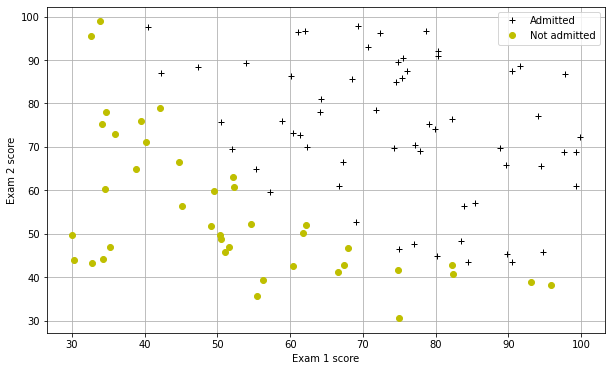

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

datafile = 'data/ex2data1.txt'

cols = np.loadtxt(datafile, delimiter=',', usecols=(0, 1, 2), unpack=True)  #Read in comma separated data
##Form the usual "X" matrix and "y" vector
X = np.transpose(np.array(cols[:-1]))
y = np.transpose(np.array(cols[-1:]))
m = y.size  # number of training examples
##Insert the usual column of 1's into the "X" matrix
X = np.insert(X, 0, 1, axis=1)

#Divide the sample into two: ones with positive classification, one with null classification
pos = np.array([X[i] for i in range(X.shape[0]) if y[i] == 1])
neg = np.array([X[i] for i in range(X.shape[0]) if y[i] == 0])

def plotData():
    plt.figure(figsize=(10, 6))
    plt.plot(pos[:, 1], pos[:, 2], 'k+', label='Admitted')
    plt.plot(neg[:, 1], neg[:, 2], 'yo', label='Not admitted')
    plt.xlabel('Exam 1 score')
    plt.ylabel('Exam 2 score')
    plt.legend()
    plt.grid(True)

plotData()


Implement the LDA classifier by completing the code below.

### 1.3 Centering the data [5 pts]
As an implementation detail, you should first center the positive and negative data separately, so that each set has a mean equal to [0, 0], before computing the covariance, as this tends to give a more accurate estimate of the covariance.

In [ ]:
##### IMPLEMENT THIS #######
pos_mean = None
neg_mean = None

pos_data = None
neg_data = None


### 1.4 Computing parameters and predictions [10 pts]
Implement the LDA algorithm here in vectorized form (avoid loops). First, compute the covariance matrix, then the classifier's weights, then use the classifier to make predictions on the training data. Note, you should center the whole training data set before applying the classifier. Namely, subtract the mean value of the two classes’ means (1/2*(pos_mean+neg_mean)), which is on the separating plane when their prior probabilities are the same and becomes the ‘center’ of the data.

In [ ]:
# IMPLEMENT THIS
cov_all = None # SHAPE: (2,2)
w = None
y_lda = None # SHAPE: (100,)


### 1.5 Training accuracy [5 pts]
Complete the code to compute the training set accuracy, which should be around 89%.  

In [ ]:
####### IMPLEMENT THIS #########
accuracy = None
print(accuracy)

89.0


### 1.6 Effect of prior [10 pts]
Try changing the prior probability of the positive class $P(y = 1) = \pi$ and show how the resulting decision boundary changes by plotting it. What is the effect of changing $\pi$ on the boundary?

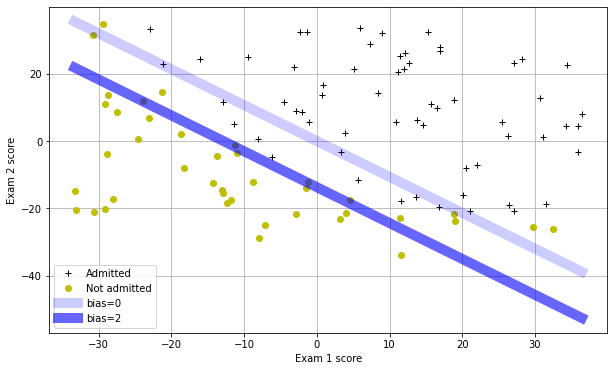

In [ ]:
# Plot decision boundary for various biases.
# Changing the prior probability of y=1 only affects the bias, specifically the
# term log(p(y=1)/p(y=0)) which is part of the bias term. The effect is to move
# the decision boundary away from the more prevalent class. So if we change pi
# to make class 1 ("+") more prevalent, the bias should increase.

# center the data, split into classes (pos "+"  and neg "o")
X_c = X[:,1:] - np.kron(np.ones((len(X), 1)),(1/2*(pos_mean + neg_mean)))
pos_c = np.array([X_c[i] for i in range(X_c.shape[0]) if y[i] == 1])
neg_c = np.array([X_c[i] for i in range(X_c.shape[0]) if y[i] == 0])

# make a new figure and plot points
plt.figure(figsize=(10, 6))
plt.plot(pos_c[:, 0], pos_c[:, 1], 'k+', label='Admitted')
plt.plot(neg_c[:, 0], neg_c[:, 1], 'yo', label='Not admitted')
plt.xlabel('Exam 1 score')
plt.ylabel('Exam 2 score')
plt.legend()
plt.grid(True)

################### IMPLEMENT THIS ###################################
# Show how the decision boundary changes with prior.
# Plotting the decision boundary: two points, draw a line between them
# Decision boundary occurs when h(x) = 0, ie when
#           w0*x1 + w1*x2 + bias = 0
# So the line y=mx+b is given by x2 = (-1/w1)(bias + w0*x1)

plt.legend()
plt.show()

## 2 Conjugate Prior [25 pts]

In this problem we will estimate the parameter $\theta$ of the coin flipping problem using the Bayesian approach. In the Bayesian approach, $\theta$ is considered a random variable sampled from some prior distribution $p(\theta)$. We represent the ith coin flip by a Bernoulli random variable $x ∈ \{0, 1\}$, where $x_i = 1$ if the ith flip lands on heads. We assume that the observed $x_i$’s are conditionally indendent given $\theta$. This means that the joint distribution of $n$ coin flips and $\theta$ can be factorized as

$$ p(x_1,...,x_n,\theta) = p(\theta) \prod_{i=1}^{n} p(x_i|\theta)  $$

Suppose that our prior distribution on $\theta$ is $Beta(h, t)$, for some $h, t > 0$. That is,

$$p(\theta) \propto \theta^{h-1}(1-\theta)^{t-1}$$

See Bishop Ch 2.1.1 or https://en.wikipedia.org/wiki/Beta_distribution for more details on this distribution. There is a nice online graphing tool here http://eurekastatistics.com/beta-distribution-pdf-grapher/.

The Beta distribution is a conjugate to the Bernoulli distribution since the prior $p(\theta)$ and posterior $p(\theta|x_1,...,x_n)$  are in the same family (the Beta family).

### 2.1 Posterior [10 pts]
Suppose our dataset of flips has $H$ heads and $T$ tails. Show that the posterior distribution fo $\theta$ is $Beta(h+H, t+T)$, i.e. show that

$$ p(\theta|x_1,...,x_n) \propto \theta^{h-1+H}(1-\theta)^{t-1+T} $$


**Answer:** [put your answer here]


### 2.2 Parameter estimates [10 pts]
Give the expressions for three estimates of $\theta$: the Maximum Likelihood ($\theta_{ML}$), the Maximum a Posteriori ($\theta_{MAP}$) or the mode of the posterior over $\theta$, and the mean of the posterior ($\theta_{MP}$).

*Hint:*
You may use the fact that a Beta(h, t) distribution has mean $h/(h + t)$ and has mode $(h − 1) / (h + t − 2)$ for $h, t > 1$.


**Answer:** [put your answer here]


### 2.3 Example [5 pts]
Supose you are modeling some event with a binary outcome (such as a user clicking on an ad after viewing it). You know that typical fractions of positive events observed in data are between 0.01 and 0.02. What are reasonable hyperparameters of the Beta prior to use, and why? Include a plot of the resulting prior PDF.

**Answer:** [put your answer here]


## 3 Bayesian Linear Regression [25 pts + 20 pts bonus]
In this exercise, we implement Bayesian regression with linear basis function models. Recall that a linear regression model $y$(**x**,**w**) can be defined more generally as

$$y(\textbf{x},\textbf{w}) = w_0 + \sum_{j=1}^{M-1} w_j \phi_j (\textbf{x}) = \sum_{j=0}^{M-1} w_j \phi_j (\textbf{x}) = \textbf{w}^T \phi(\textbf{x})$$

where $\phi_j$ are basis functions and $M$ is the total number of parameters $w_j$ including the bias term $w_0$.
The target variable $t$ of an observation $\textbf{x}$ is given by a deterministic function $y(\textbf{x}, \textbf{w})$ plus additive random noise $\epsilon$.

$$t = y(\textbf{x}, \textbf{w}) + \epsilon $$

We assume that the noise is normally distributed i.e. follows a Gaussian distribution with zero mean and precision (inverse variance) $\beta$. The corresponding probabilistic model i.e. the conditional distribution of $t$ given $\textbf{x}$ can therefore be written as

$$p(t|\textbf{x},\textbf{w},\beta) = \mathcal{N}(t|y(\textbf{x}, \textbf{w}), \beta^{-1}) = \sqrt{\frac{\beta}{2\pi}} \text{exp}\left(-\frac{\beta}{2}(t - y(\textbf{x},\textbf{w}))^2\right)$$

where the mean of this distribution is the regression function $y(\textbf{x}, \textbf{w})$.

### 3.1 Posterior and posterior predictive distribution [10pts]
For a Bayesian treatment of linear regression, we need a prior probability distribution over the model parameters $\textbf{w}$ with zero mean:

$$p(\textbf{w} | \alpha) = \mathcal{N}(\textbf{w}|0,\alpha^{-1} \textbf{I})$$

where $\alpha^{-1}I$ is the diagonal covariance matrix where all diagonal elements have the same variance $\alpha^{-1}$.


The posterior distribution has the following mean and inverse covariance matrix:

$$m_N = \beta \textbf{S}_N \Phi^T \textbf{t}$$
$$\textbf{S}^{-1}_N = \alpha \textbf{I} + \beta \Phi^{T} \Phi$$

Hence, the posterior distribution can be written as
$$p(\textbf{w}|\textbf{t},\alpha,\beta) = \mathcal{N}(\textbf{w}|\textbf{m}_N, \textbf{S}_N)$$

For making a prediction $t$ at a new location $\textbf{x}$ we use the posterior predictive distribution which is defined as

$$p(t|\textbf{t},\textbf{w},\alpha,\beta) = \int p(t|\textbf{x},\textbf{w},\beta) p(\textbf{w}|\textbf{t},\alpha,\beta) d\textbf{w}$$


Implement the posterior and posterior predictive distributions.

In [ ]:
import numpy as np

def posterior(Phi, t, alpha, beta, return_inverse=False):
    """Computes mean and covariance matrix of the posterior distribution."""

    raise NotImplementedError

    if return_inverse:
        return m_N, S_N, S_N_inv
    else:
        return m_N, S_N


def posterior_predictive(Phi_test, m_N, S_N, beta):
    """Computes mean and variances of the posterior predictive distribution."""

    raise NotImplementedError

    return y, y_var

### 3.2 Generating the data [5pts]
Target values $\textbf{t}$ are generated from the design matrix **X** $\in \mathbb{R}^{N\times 1}$ with a linear function $f$ which can also generate random noise of specified variance. Implement $f$ below.

In [ ]:
w0 = -0.3  # line offset
w1 =  0.5  # line slope

def f(X, noise_variance):
    '''Linear function plus noise'''
    raise NotImplementedError

def noise(size, variance):
    return np.random.normal(scale=np.sqrt(variance), size=size)

### 3.3 Basis functions [5pts]
For straight line fitting, we do not need to transform $x$ with a basis function, which is equivalent to using an identity basis function. Other basis functions that are non-linear are necessary to model the non-linear relationship between input $x$ and target $t$. Below is an example of non-linear basis functions: the polynomial. Implement the polynomial basis function. *Note: You will not use it in the rest of the exercise but your implementation should be reasonable.*

In [ ]:
def identity_basis_function(x):
    return x


def polynomial_basis_function(x, power):
    raise NotImplementedError


def expand(x, bf, bf_args=None):
    if bf_args is None:
        return np.concatenate([np.ones(x.shape), bf(x)], axis=1)
    else:
        return np.concatenate([np.ones(x.shape)] + [bf(x, bf_arg) for bf_arg in bf_args], axis=1)

### 3.3 Straight line fitting [5pts]
For straight line fitting, we use a linear regression model of the form $y(\textbf{w},\textbf{x}) = w_0 + w_1 x$ and perform Bayesian inference for model parameters $\textbf{w}$. Predictions are made with the posterior predictive distribution. Since this model has only two parameters, $w_0$ and $w_1$, we can visualize the posterior density in 2D which is done in the first column of the following output. Rows use an increasing number of training data from a training dataset.

**Question:** Run the code below. How does the dataset size affect the posterior density in the first column of the plots?

**Answer:**

In [ ]:
from scipy import stats
import matplotlib.pyplot as plt

def plot_data(x, t):
    plt.scatter(x, t, marker='o', c="k", s=20)


def plot_truth(x, y, label='Truth'):
    plt.plot(x, y, 'k--', label=label)


def plot_predictive(x, y, std, y_label='Prediction', std_label='Uncertainty', plot_xy_labels=True):
    y = y.ravel()
    std = std.ravel()

    plt.plot(x, y, label=y_label)
    plt.fill_between(x.ravel(), y + std, y - std, alpha = 0.5, label=std_label)

    if plot_xy_labels:
        plt.xlabel('x')
        plt.ylabel('y')


def plot_posterior_samples(x, ys, plot_xy_labels=True):
    plt.plot(x, ys[:, 0], 'r-', alpha=0.5, label='Post. samples')
    for i in range(1, ys.shape[1]):
        plt.plot(x, ys[:, i], 'r-', alpha=0.5)

    if plot_xy_labels:
        plt.xlabel('x')
        plt.ylabel('y')


def plot_posterior(mean, cov, w0, w1):
    resolution = 100

    grid_x = grid_y = np.linspace(-1, 1, resolution)
    grid_flat = np.dstack(np.meshgrid(grid_x, grid_y)).reshape(-1, 2)

    densities = stats.multivariate_normal.pdf(grid_flat, mean=mean.ravel(), cov=cov).reshape(resolution, resolution)
    plt.imshow(densities, origin='lower', extent=(-1, 1, -1, 1))
    plt.scatter(w0, w1, marker='x', c="r", s=20, label='Truth')

    plt.xlabel('w0')
    plt.ylabel('w1')


def print_comparison(title, a, b, a_prefix='np', b_prefix='br'):
    print(title)
    print('-' * len(title))
    print(f'{a_prefix}:', a)
    print(f'{b_prefix}:', b)
    print()

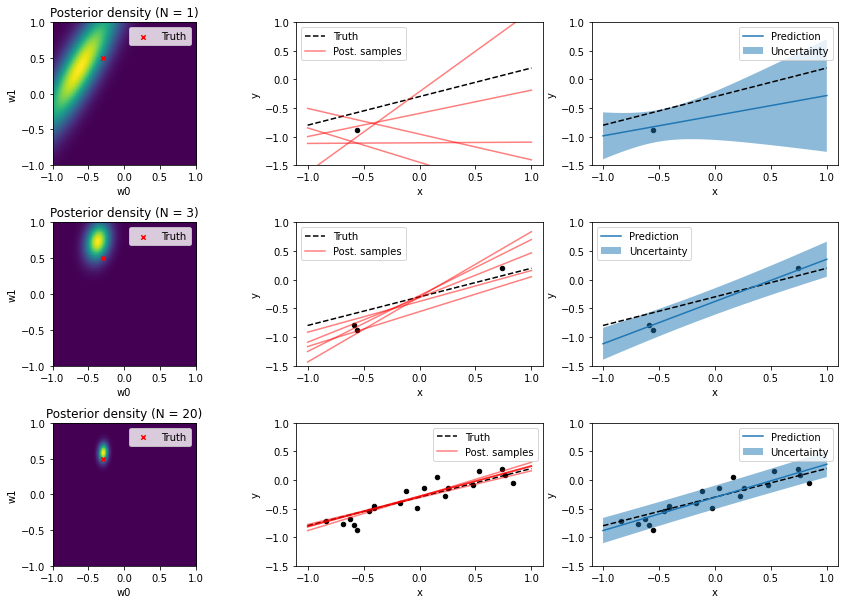

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

# fix random seed so we always get the same data
np.random.seed(5)

# Training dataset sizes
N_list = [1, 3, 20]

beta = 25.0
alpha = 2.0

# Training observations in [-1, 1)
X = np.random.rand(N_list[-1], 1) * 2 - 1

# Training target values
t = f(X, noise_variance=1/beta)

# Test observations
X_test = np.linspace(-1, 1, 100).reshape(-1, 1)

# Function values without noise
y_true = f(X_test, noise_variance=0)

# Design matrix of test observations
Phi_test = expand(X_test, identity_basis_function)

plt.figure(figsize=(15, 10))
plt.subplots_adjust(hspace=0.4)

for i, N in enumerate(N_list):
    X_N = X[:N]
    t_N = t[:N]

    # Design matrix of training observations
    Phi_N = expand(X_N, identity_basis_function)

    # Mean and covariance matrix of posterior
    m_N, S_N = posterior(Phi_N, t_N, alpha, beta)

    # Mean and variances of posterior predictive
    y, y_var = posterior_predictive(Phi_test, m_N, S_N, beta)

    # Draw 5 random weight samples from posterior and compute y values
    w_samples = np.random.multivariate_normal(m_N.ravel(), S_N, 5).T
    y_samples = Phi_test.dot(w_samples)

    plt.subplot(len(N_list), 3, i * 3 + 1)
    plot_posterior(m_N, S_N, w0, w1)
    plt.title(f'Posterior density (N = {N})')
    plt.legend()

    plt.subplot(len(N_list), 3, i * 3 + 2)
    plot_data(X_N, t_N)
    plot_truth(X_test, y_true)
    plot_posterior_samples(X_test, y_samples)
    plt.ylim(-1.5, 1.0)
    plt.legend()

    plt.subplot(len(N_list), 3, i * 3 + 3)
    plot_data(X_N, t_N)
    plot_truth(X_test, y_true, label=None)
    plot_predictive(X_test, y, np.sqrt(y_var))
    plt.ylim(-1.5, 1.0)
    plt.legend()

### 3.4 Bonus [20pts] (optional)
We now fit a Gaussian basis function model to a noisy sinusoidal dataset for which we provide a sinusoidal function $g$ with noise variance. Implement the gaussian basis function below.

The model uses 7 Gaussian basis functions with mean values equally distributed over [0,1] each having a standard deviation of 0.1. We then infer the model parameters **w** using the posterior predictive distribution.

How many parameters $w_i$ are there? Run Bayesian inference and generate the plots. Do they follow the same trend as the ones generated by Bayesian linear regression?

**Answer:**

In [ ]:
def g(X, noise_variance):
    '''Sinusoidial function plus noise'''
    return 0.5 + np.sin(2 * np.pi * X) + noise(X.shape, noise_variance)

def gaussian_basis_function(x, mu, sigma=0.1):
    raise NotImplementedError


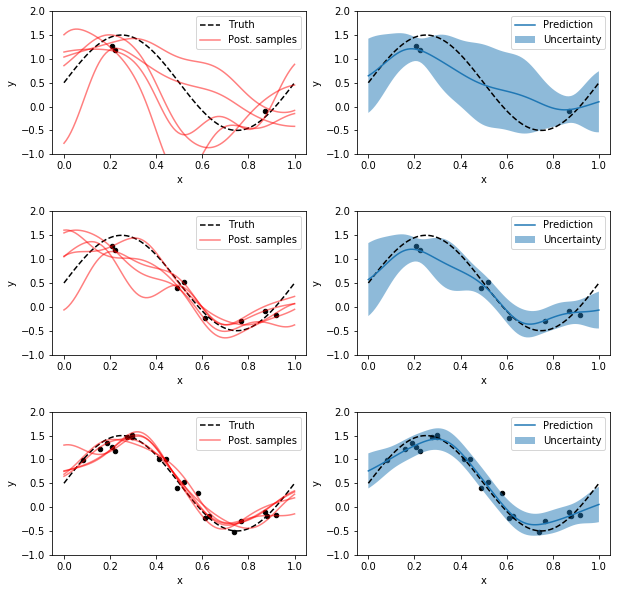

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline
from scipy.optimize import curve_fit

# fix random seed so we always get the same data
np.random.seed(5)

N_list = [3, 8, 20]

beta = 25.0
alpha = 2.0

# Training observations in [-1, 1)
X = np.random.rand(N_list[-1], 1)

# Training target values
t = g(X, noise_variance=1/beta)

# Test observations
X_test = np.linspace(0, 1, 100).reshape(-1, 1)

# Function values without noise
y_true = g(X_test, noise_variance=0)

# Design matrix of test observations
Phi_test = expand(X_test, bf=gaussian_basis_function, bf_args=np.linspace(0, 1, 7))

plt.figure(figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

for i, N in enumerate(N_list):
    X_N = X[:N]
    t_N = t[:N]

    # Design matrix of training observations
    Phi_N = expand(X_N, bf=gaussian_basis_function, bf_args=np.linspace(0, 1, 7))

    # Mean and covariance matrix of posterior
    m_N, S_N = posterior(Phi_N, t_N, alpha, beta)

    # Mean and variances of posterior predictive
    y, y_var = posterior_predictive(Phi_test, m_N, S_N, beta)

    # Draw 5 random weight samples from posterior and compute y values
    w_samples = np.random.multivariate_normal(m_N.ravel(), S_N, 5).T
    y_samples = Phi_test.dot(w_samples)

    plt.subplot(len(N_list), 2, i * 2 + 1)
    plot_data(X_N, t_N)
    plot_truth(X_test, y_true)
    plot_posterior_samples(X_test, y_samples)
    plt.ylim(-1.0, 2.0)
    plt.legend()

    plt.subplot(len(N_list), 2, i * 2 + 2)
    plot_data(X_N, t_N)
    plot_truth(X_test, y_true, label=None)
    plot_predictive(X_test, y, np.sqrt(y_var))
    plt.ylim(-1.0, 2.0)
    plt.legend()



---


## 4 Reinforcement Learning [25 pts]
In this problem, you will implement the Q-Learning Algorithm to solve the "Frozen Lake" problem.
We​ ​will​ ​use​ ​OpenAI’s​ ​gym​ ​package​ ​to​ ​develop​ ​our​ ​solution​ ​in​ ​Python.​

### OpenAI Gym  
Gym is a standard API for reinforcement learning, and a diverse collection of reference environments. ​You can read the basic setup instructions for​ ​Gym​  [here](https://www.gymlibrary.dev/content/basic_usage/).​ ​

### Frozen Lake
We’re​ ​going​ ​to​ ​be​ ​using​ ​the​ [​​FrozenLake](https://www.gymlibrary.dev/environments/toy_text/frozen_lake/) environment. You can read through the code for this environment by following the Github link.​ <br>

![link text](https://www.gymlibrary.dev/_images/frozen_lake.gif)

Winter​ ​is​ ​quickly​ ​approaching,​ ​and​ the agent ​has​ ​to​ ​worry​ ​about​ ​navigating​ ​frozen​ ​lakes.​ ​It’s​ ​only early November,​ ​
so​ ​the​ ​lakes​ ​haven’t​ ​completely​ ​frozen​ ​and​ ​if​ ​you​ ​make​ ​the​ ​wrong​ ​step​ ​you​ ​may​ ​fall​ ​through!
The agent will​ ​need​ ​to​ ​learn​ ​how​ ​to​ ​get​ ​to​ the ​destination​ ​when​ ​stuck​ ​on​ ​the​ ​ice,​ ​without​ ​falling​ ​in.
The​ ​lake​ ​we’re​ ​going​ ​to​ ​consider​ ​is a​ ​square​ ​lake​ ​with​ ​spots​ ​to​ ​step​ ​on​ ​in​ ​the​ ​shape​ ​of​ ​a​ ​grid.​ ​​<br>

The surface is described using a 4x4 grid of "states":

        S F F F
        F H F H
        F F F H
        H F F G

The corresponding state ids are

        0  1  2  3
        4  5  6  7
        8  9  10 11
        12 13 14 15

​Each​ ​spot​ ​can have​ ​one​ ​of​ ​four​ ​states:
- S:​ ​starting​ ​point.
- G:​ ​goal​ ​point.
- F:​ ​frozen​ ​spot,​ ​where​ ​it’s​ ​safe​ ​to​ ​walk.
- H:​ ​hole​ ​in​ ​the​ ​ice,​ ​where​ ​it’s​ ​not​ ​safe​ ​to​ ​walk.<br>

The action space (the set of possible actions the agent can take) is discrete with 4 actions available 🎮:
- 0: GO LEFT
- 1: GO DOWN
- 2: GO RIGHT
- 3: GO UP

Reward function 💰:
- Reach goal: +1
- Reach hole: 0
- Reach frozen: 0

Although we​ ​can​ ​see​ ​the​ ​path​ ​we​ ​need​ ​to​ ​walk,​ the agent does not. ​We’re​ ​going​ ​to​ ​train​ ​an​ ​agent​ ​to​ ​discover​ ​this​ ​via​ reinforcement learning.​ ​However,​ ​walking​ ​on​ ​ice​ ​isn’t​ ​so​ ​easy!​ ​Sometimes​ ​you​ ​slip​ ​and​ ​aren’t​ ​able​ ​to​ ​take​ ​the​ ​step​ ​you intended. In our environment, this is controlled by setting `is_slippery: True/False`. If `True`, each step will move in intended direction with probability of 1/3, else will move in either perpendicular direction with equal probability of 1/3 in each directions.

The episode ends when the agent reaches the goal or falls in a hole. The agent receives a reward of 1 upon reaching the goal, and zero otherwise.



### 4.0 Install dependencies

In [ ]:
!pip install gym==0.25.2
!pip install pygame
!pip install numpy

### 4.1. Walking on the Frozen Lake [5 points]

The script below sets up the Frozen Lake environment and takes 10 walks through it, consisting of a maximum 10 randomly sampled actions during each walk. After each step, it prints the current state id, and prints out the reward and whether the walk is "done", i.e. in the terminal state, because the agent fell into a hole (stop if it is).

The environment behaves in a stochastic way, i.e. taking an action does not  deterministically transition the agent into the next state. Instead the agent ends up in one of several states with some probability. The analogy here is that when you try to walk right on ice, you may slip and end up walking forward, etc.

Run the script and make sure you understand the behavior of the agent. Is it easy for the agent to reach the goal while taking random actions? Read the code to understand what it's doing (there is nothing to implement for this part).

In [ ]:
import numpy as np
import gym

In [ ]:
#env = gym.make("FrozenLake-v1", map_name="4x4", is_slippery=False)
env =gym.make("FrozenLake-v1", new_step_api=True).unwrapped
np.random.seed(42)
actions = ["LEFT", "DOWN", "RIGHT", "UP"]

# Do a random walk
for i in range(2):
  env.reset()
  print("Walk %d" % i)
  for _ in range(10):
    #env.render() # note, this does not work in Colab
    action = env.action_space.sample()
    next_state, reward, done, info, prob = env.step(action) # take a random action
    print("Action %s \t State %d Reward %d done? %d" % (actions[action], next_state, reward, done))
  env.close()


Walk 0
Action LEFT 	 State 0 Reward 0 done? 0
Action UP 	 State 0 Reward 0 done? 0
Action RIGHT 	 State 0 Reward 0 done? 0
Action UP 	 State 0 Reward 0 done? 0
Action DOWN 	 State 4 Reward 0 done? 0
Action LEFT 	 State 4 Reward 0 done? 0
Action LEFT 	 State 4 Reward 0 done? 0
Action RIGHT 	 State 5 Reward 0 done? 1
Action UP 	 State 5 Reward 0 done? 1
Action RIGHT 	 State 5 Reward 0 done? 1
Walk 1
Action RIGHT 	 State 0 Reward 0 done? 0
Action RIGHT 	 State 0 Reward 0 done? 0
Action DOWN 	 State 1 Reward 0 done? 0
Action RIGHT 	 State 1 Reward 0 done? 0
Action DOWN 	 State 5 Reward 0 done? 1
Action DOWN 	 State 5 Reward 0 done? 1
Action DOWN 	 State 5 Reward 0 done? 1
Action UP 	 State 5 Reward 0 done? 1
Action DOWN 	 State 5 Reward 0 done? 1
Action DOWN 	 State 5 Reward 0 done? 1


### 4.2 Q-Learning Implementation [20 points]
Below we have provided most of the code to solve the  FrozenLake problem, including setting up the Gym environment,
calling the Q-learning function, and printing out the returned Q-table. <br>

**Your task** is to understand the provided code and fill in the missing part. Run the code, provide​ ​the​ ​final​ ​Q-table​ ​of​ ​​FrozenLake for **each <num_episode, init_method>** tried,​ ​and analyze ​what​ you observe.

####Notes
We use the $\epsilon$-greedy algorithm (solving Exploration-Exploitation Dilemma) to generate actions for each state. The code tries `num_episodes` with different values, e.g. `num_episodes=500, 1000, 5000, 10000, 50000`. It also tries different initializations for the Q-table, i.e. Random Initialization and Zero Initialization.

Please do not change any default value of environment setting, such as `is_slippery`.

To test the learned Q-table, we can compute the win rate (the probability of agents getting to goal following the Q-table). Note that in this case, we should use `argmax` instead of epsilon greedy to choose the action at the current state. Win Rate is a good way to test whether you write your algorithm correctly.

Just for your reference, we tested our implementation several times with 1000 trials after 50000-episode training using zero initialization, and were able to achieve a win rate of 0.5 or higher on several of the trials.



In [ ]:
# whether to initialize Q-table randomly
RAND = False

"""   Performs   Q-learning   for   the   given   environment.
Initialize Q to all zeros or randomly.
:param   env:   Unwrapped   OpenAI   gym   environment.
:param   alpha:   Learning   rate   parameter.
:param   gamma:   Decay   rate   parameter.
:param   num_episodes:   Number   of   episodes   to   use   for   learning. :return:   Q   table.
"""
def q_learning(env, alpha=0.5, gamma=0.95, epsilon=0.1, num_episodes=500):
  np.random.seed(42)
  # initialize Q
  state_num = env.observation_space.n
  action_num = env.action_space.n
  Q = np.zeros((state_num, action_num))

  if RAND:
    Q = np.random.rand(state_num, action_num)
    terminal_state = [5, 7, 11, 12, 15]
    Q[terminal_state, :] = 0

  for episode in range(num_episodes):
    current_state = env.reset()
    done = False
    while not done:
      if np.random.rand()< 1- epsilon:
        action = np.argmax(Q[current_state,:])
      else:
        action = np.random.randint(0,action_num)

      # IMPLEMENT THIS (see lecture notes for pseudocode):
      #  - carry out selected action
      #  - observe reward and new state
      #  - update the Q table
      #  - update current state to new state
      raise NotImplementedError

  return Q

def winrate(Q, env, num_episodes):
    num_win = 0.

    for episode in range(num_episodes):
        current_state = env.reset()
        done = False
        while not done:
            action = np.argmax(Q[current_state, :])
            next_state, reward, done, info, prob = env.step(action)
            num_win += reward
            current_state = next_state

    return num_win/num_episodes

# MAIN function that runs Q-learning for Frozen Lake
def main():
	env =gym.make("FrozenLake-v1", new_step_api=True).unwrapped
	np.random.seed(42)

	print("output of Q-learning")
	Q = q_learning(env, num_episodes=50000)
	print("Q: ", Q)
	print("Win rate: ", winrate(Q, env, num_episodes=1000))

if __name__ == "__main__":
	main()

output of Q-learning
Q:  [[0.18013471 0.17631107 0.17743527 0.162024  ]
 [0.04051972 0.18261163 0.08089756 0.13842205]
 [0.0906516  0.09764737 0.09810399 0.10429152]
 [0.00885868 0.01462246 0.07407882 0.09241819]
 [0.24449008 0.11913243 0.13454219 0.04782118]
 [0.         0.         0.         0.        ]
 [0.01438285 0.0075254  0.06145101 0.00455647]
 [0.         0.         0.         0.        ]
 [0.13852529 0.00454821 0.24567321 0.35937816]
 [0.08158036 0.37199869 0.2774429  0.17406142]
 [0.24997079 0.13045345 0.07353985 0.16431143]
 [0.         0.         0.         0.        ]
 [0.         0.         0.         0.        ]
 [0.08593627 0.20679063 0.6508868  0.15243835]
 [0.46005482 0.50896042 0.93088357 0.46263803]
 [0.         0.         0.         0.        ]]
Win rate:  0.636


**[[Write your analysis here]]**